## פעולות חשבון על מערכים: איבר-איבר, פונקציות מתמטיות וסקלר מול מערך

ראינו כבר ש-`+`, `-`, `*`, `/` על שני מערכים מבצעים פעולה **איבר-איבר**. אותו עיקרון חל גם על פונקציות מתמטיות: `np.sqrt`, `np.exp`, `np.log`, `np.sin`, `np.cos` וכדומה מקבלות מערך שלם ומחזירות מערך של אותו גודל, עם הפונקציה מופעלת על כל איבר בנפרד. פונקציות כאלה נקראות **ufuncs** (universal functions).

כאשר פועלים על מערך יחד עם **סקלר** בודד (מספר רגיל), הסקלר "מוחל" על כל איברי המערך — למשל `a * 2` מכפיל כל איבר ב-2. זהו המקרה הפשוט ביותר של broadcasting; נרחיב על הכלל המלא בשבוע 9.

```{warning}
כל הפונקציות הטריגונומטריות ב-NumPy (`sin`, `cos`, `tan`) מצפות לזווית **ברדיאנים**, לא במעלות. שכחת ההמרה היא אחת מהטעויות הנפוצות ביותר בתרגום נוסחה פיזיקלית לקוד.
```

```{admonition} 🎥 כאן נכנס סרטון השבוע
:class: seealso

**"ממשוואה לקוד: פעולות איבר-איבר, רדיאנים, שגיאות תרגום"** (כ-6–10 דקות, הקלטת מסך של המחברת עם קול).

<!-- TODO (למפיק/ה): להחליף תא זה בהטמעת הסרטון בפועל, למשל:
<iframe width="100%" height="400" src="VIDEO_URL_HERE" title="שבוע 7 — ממשוואה לקוד" frameborder="0" allowfullscreen></iframe>
-->
```

### דוגמה: רכיבי המהירות בזריקה בזווית

כדור נזרק בזווית $\theta$ מעל האופק, במהירות התחלתית $v_0$. רכיבי המהירות בזמן $t$ נתונים על ידי:

$$v_x(t) = v_0 \cos\theta \qquad v_y(t) = v_0 \sin\theta - g t$$

$v_x$ קבוע בזמן; $v_y$ תלוי בזמן. נחשב את שניהם עבור זווית שיגור של $45°$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g, v0 = 9.8, 20.0
theta_deg = 45
theta = np.radians(theta_deg)   # המרה הכרחית לפני שימוש בפונקציה טריגונומטרית

t = np.linspace(0, 3, 30)
vx = v0 * np.cos(theta) * np.ones_like(t)   # קבוע — אבל שומרים על אותו shape כמו t
vy = v0 * np.sin(theta) - g * t

print("vx[0:5] =", vx[:5])
print("vy[0:5] =", vy[:5])

vx[0:5] = [14.14213562 14.14213562 14.14213562 14.14213562 14.14213562]
vy[0:5] = [14.14213562 13.12834252 12.11454942 11.10075631 10.08696321]


נצייר את שני רכיבי המהירות כפונקציה של זמן:

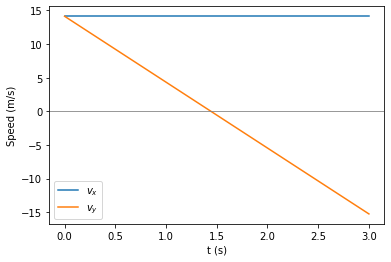

In [2]:
fig, ax = plt.subplots()
ax.plot(t, vx, label="$v_x$")
ax.plot(t, vy, label="$v_y$")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("t (s)")
ax.set_ylabel("Speed (m/s)")
ax.legend()
plt.show()

### נסו בעצמכם

חשבו את **גודל** המהירות הכולל $|v(t)| = \sqrt{v_x^2 + v_y^2}$ בכל נקודת זמן, בפעולה וקטורית אחת:

In [3]:
# speed = ...
# print(speed[:5])

`````{admonition} פתרון
:class: dropdown, tip
```python
speed = np.sqrt(vx**2 + vy**2)
print(speed[:5])
```
`````

### מעלות מול רדיאנים — למה זה קריטי

נבדוק מה קורה אם שוכחים להמיר את הזווית לרדיאנים:

In [4]:
wrong_vy0 = v0 * np.sin(theta_deg)   # שכחו את np.radians!
correct_vy0 = v0 * np.sin(np.radians(theta_deg))

print("שגוי (מעלות ישירות):", wrong_vy0)
print("נכון (אחרי המרה לרדיאנים):", correct_vy0)

שגוי (מעלות ישירות): 17.01807049068237
נכון (אחרי המרה לרדיאנים): 14.14213562373095


התוצאה השגויה אינה מייצרת שגיאת ריצה — `np.sin` מקבל כל מספר בלי לבדוק אם הוא סביר כזווית. זו הסיבה שהבאג הזה קשה לאיתור: הקוד "עובד", אך מחזיר תוצאה פיזיקלית שגויה.

### בדקו את עצמכם

In [5]:
from jupyterquiz import display_quiz

questions = [
    {
        "question": "מה יחזיר <code>np.sin(90)</code> (בלי המרה לרדיאנים)?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "1.0, כמו sin(90°)", "correct": False, "feedback": "לא — NumPy מפרש את 90 כ-90 רדיאן, לא 90 מעלות."},
            {"answer": "שגיאת ריצה, כי 90 גדול מדי", "correct": False, "feedback": "לא — sin מוגדרת לכל מספר ממשי, אין שגיאה."},
            {"answer": "0.0, כי sin של זווית גדולה תמיד מתאפס", "correct": False, "feedback": "לא — אין סיבה ש-sin יתאפס דווקא ב-90 רדיאן; התוצאה היא ≈0.894."},
            {"answer": "ערך כלשהו בין -1 ל-1, שאינו 1.0", "correct": True, "feedback": "נכון: sin(90 רדיאן) ≈ 0.894, כי 90 רדיאן הן זווית ענקית (הרבה סיבובים מלאים)."}
        ]
    },
    {
        "question": "בהינתן מערך <code>a = np.array([1, 4, 9])</code>, מה מחזיר <code>np.sqrt(a)</code>?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "מערך [1, 2, 3]", "correct": True, "feedback": "נכון: שורש כל איבר בנפרד."},
            {"answer": "מספר בודד — שורש הסכום", "correct": False, "feedback": "לא — sqrt הוא ufunc, פועל על כל איבר בנפרד."},
            {"answer": "שגיאה, כי sqrt לא עובד על מערכים", "correct": False, "feedback": "לא — זו בדיוק המטרה של ufuncs."},
            {"answer": "מערך [1, 16, 81] — כל איבר בריבוע", "correct": False, "feedback": "לא — זו הייתה התוצאה של a**2, לא של np.sqrt(a)."}
        ]
    }
]

display_quiz(questions)

<IPython.core.display.Javascript object>

### תרגול עצמי

עבור מערך מהירויות $v$ שנמדדו בניסוי (ביחידות m/s) וכדור בעל מסה $m = 0.2\ \text{kg}$, חשבו את מערך האנרגיה הקינטית $E_k = \tfrac{1}{2} m v^2$ המתאים לכל מדידה, בפעולה וקטורית אחת:

In [6]:
m = 0.2
v_measured = np.array([3.2, 5.1, 7.8, 2.4, 6.0])

# E_k = ...
# print(E_k)

`````{admonition} פתרון
:class: dropdown, tip
```python
E_k = 0.5 * m * v_measured**2
print(E_k)
```
`````